# **Exploratory Data Analysis on Online Course Enrollment Data**


Before building a personalized online courses recommender system, it's essential to explore the available data. This exploratory data analysis will help uncover patterns and insights in the course content and enrollment data.


## Objectives


This analysis will:

* Calculate summary statistics for the online course content dataset
* Determine popular course genres
* Analyze online course enrollment patterns
* Identify the most popular courses by enrollment


----


## Environment Setup


Importing necessary libraries:


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [16]:
# Setting random state for reproducibility
rs = 123

## Data Loading and Initial Exploration


Loading the datasets as Pandas dataframes:


In [17]:
course_df = pd.read_csv("data/course_genre.csv")
ratings_df = pd.read_csv("data/ratings.csv")

### Course Genre Dataset Exploration


Examining the columns/features of the course genre dataset:


In [18]:
course_df.columns

Index(['COURSE_ID', 'TITLE', 'Database', 'Python', 'CloudComputing',
       'DataAnalysis', 'Containers', 'MachineLearning', 'ComputerVision',
       'DataScience', 'BigData', 'Chatbot', 'R', 'BackendDev', 'FrontendDev',
       'Blockchain'],
      dtype='object')

The columns represent metadata about each course, including its ID, title, and associated genres related to machine learning, databases, app development, and other IT topics.


Checking the number of unique courses in the dataset:


In [19]:
course_df.shape[0]

307

Examining the first few rows of the dataset:


In [20]:
course_df.head()

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,ML0201EN,robots are coming build iot apps with watson ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
1,ML0122EN,accelerating deep learning with gpu,0,1,0,0,0,1,0,1,0,0,0,0,0,0
2,GPXX0ZG0EN,consuming restful services using the reactive ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
3,RP0105EN,analyzing big data in r using apache spark,1,0,0,1,0,0,0,0,1,0,1,0,0,0
4,GPXX0Z2PEN,containerizing packaging and running a sprin...,0,0,0,0,1,0,0,0,0,0,0,1,0,0


In [21]:
course_df.dtypes

COURSE_ID          object
TITLE              object
Database            int64
Python              int64
CloudComputing      int64
DataAnalysis        int64
Containers          int64
MachineLearning     int64
ComputerVision      int64
DataScience         int64
BigData             int64
Chatbot             int64
R                   int64
BackendDev          int64
FrontendDev         int64
Blockchain          int64
dtype: object

The `COURSE_ID` and `TITLE` columns have string data types, while all course genre columns are binary integers. A value of 1 indicates that the course is associated with that genre, while 0 indicates it is not.


Example: The course "accelerating deep learning with gpu" is associated with the genres `Python`, `MachineLearning`, and `DataScience`:


In [22]:
course_df.iloc[1, ]

COURSE_ID                                     ML0122EN
TITLE              accelerating deep learning with gpu
Database                                             0
Python                                               1
CloudComputing                                       0
DataAnalysis                                         0
Containers                                           0
MachineLearning                                      1
ComputerVision                                       0
DataScience                                          1
BigData                                              0
Chatbot                                              0
R                                                    0
BackendDev                                           0
FrontendDev                                          0
Blockchain                                           0
Name: 1, dtype: object

## Course Genre Analysis


### Finding Machine Learning Related Courses


In [23]:
ml_courses = course_df[course_df["MachineLearning"] == 1]
ml_courses.head()

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
1,ML0122EN,accelerating deep learning with gpu,0,1,0,0,0,1,0,1,0,0,0,0,0,0
15,DAI101EN,data ai essentials,0,0,0,0,0,1,0,0,0,0,0,0,0,0
19,HCC105EN,ybrid cloud conference ai pipelines lab,0,0,0,0,0,1,0,0,0,0,0,0,0,0
21,DS0132EN,data ai jumpstart your journey,0,0,0,0,0,1,0,0,0,0,0,0,0,0
24,BENTEST4,ai for everyone master the basics,0,0,0,0,0,1,0,0,0,0,0,0,0,0


### Finding Scalable Machine Learning Courses (Machine Learning and Big Data)


In [24]:
scalable_ml_courses = course_df[(course_df["MachineLearning"] == 1) & (course_df["BigData"] == 1)]
scalable_ml_courses.head()

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
46,GPXX0BUBEN,insurance risk assessment with montecarlo meth...,0,0,0,0,0,1,0,0,1,0,0,0,0,0
59,TA0106EN,text analytics at scale,0,0,0,0,0,1,0,1,1,0,0,0,0,0
184,BD0221EN,spark mllib,0,0,0,0,0,1,0,0,1,0,0,0,0,0
282,excourse69,machine learning with big data,0,0,0,0,0,1,0,0,1,0,0,0,0,0


In [25]:
genres = course_df.columns[2:]
genres

Index(['Database', 'Python', 'CloudComputing', 'DataAnalysis', 'Containers',
       'MachineLearning', 'ComputerVision', 'DataScience', 'BigData',
       'Chatbot', 'R', 'BackendDev', 'FrontendDev', 'Blockchain'],
      dtype='object')

### Course Counts by Genre

Calculating and sorting the number of courses per genre to identify the most popular categories:


In [26]:
genre_counts = course_df.iloc[:,2:].sum().sort_values(ascending = False)

Visualizing the course genre counts with a bar chart:


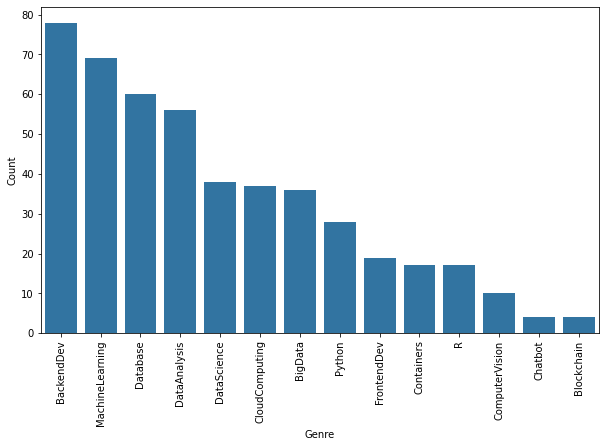

In [27]:
fig, ax = plt.subplots(1, figsize = (10,6))
sns.barplot(x = genre_counts.index, y = genre_counts.values)
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation = 90)
plt.show()

## Course Enrollment Analysis


Examining the course enrollments dataset:


In [28]:
ratings_df.head()

,user,item,rating
0,1889878,CC0101EN,5
1,1342067,CL0101EN,3
2,1990814,ML0120ENv3,5
3,380098,BD0211EN,5
4,779563,DS0101EN,3


This dataset contains three columns:
- `user`: A unique user ID
- `item`: A course ID corresponding to the COURSE_ID in the course genre dataset
- `rating`: The rating given by the user


In [29]:
ratings_df['rating'].unique()

array([5, 3, 4])

The **rating** column values represent:

- **5**: Excellent course, highest rating, recommended to other learners
- **4**: Good course, recommended with minor improvements
- **3**: Below expectations, needs significant modifications


Checking the total number of ratings in the dataset:


In [30]:
ratings_df.shape[0]

233306

### User Engagement Analysis

Aggregating the rating count for each user to understand engagement patterns:


In [31]:
rating_counts = ratings_df.groupby("user").size()

Getting summary statistics of user enrollment patterns:


In [32]:
rating_counts.describe()

count    33901.000000
mean         6.881980
std          5.823548
min          1.000000
25%          2.000000
50%          6.000000
75%          9.000000
max         61.000000
dtype: float64

Visualizing the distribution of user rating counts with a histogram:


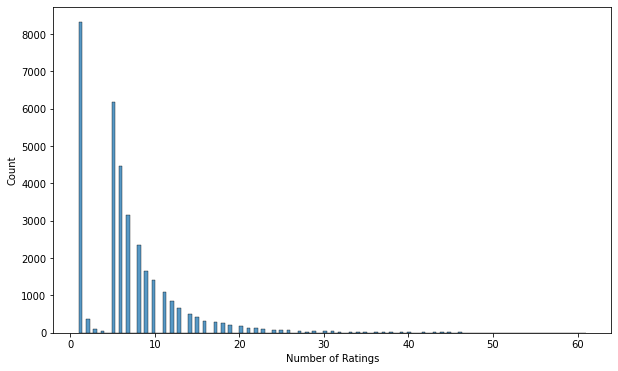

In [33]:
fig, ax = plt.subplots(figsize = (10,6))
sns.histplot(x = rating_counts.values)
plt.xlabel("Number of Ratings")
plt.ylabel("Count")
plt.show()

## Most Popular Courses Analysis


Identifying the 20 most popular courses by number of ratings:


In [34]:
course_ratings_count = ratings_df.groupby("item").size().sort_values(ascending = False)
course_ratings_count.iloc[0:20]

item
PY0101EN      14936
DS0101EN      14477
BD0101EN      13291
BD0111EN      10599
DA0101EN       8303
DS0103EN       7719
ML0101ENv3     7644
BD0211EN       7551
DS0105EN       7199
BC0101EN       6719
DV0101EN       6709
ML0115EN       6323
CB0103EN       5512
RP0101EN       5237
ST0101EN       5015
CC0101EN       4983
CO0101EN       4480
DB0101EN       3697
BD0115EN       3670
DS0301EN       3624
dtype: int64

Joining the course titles with the rating counts to better identify the popular courses:


In [35]:
course_ratings_count_df = pd.DataFrame({"course": course_ratings_count.index,
                           "ratings_count": course_ratings_count.values})

enrolls_count = pd.merge(course_ratings_count_df,
                         course_df[["COURSE_ID", "TITLE"]],
                         how = "left",
                         left_on = "course",
                         right_on = "COURSE_ID")[["TITLE", "ratings_count"]]
enrolls_count.head(20)

,TITLE,ratings_count
0,python for data science,14936
1,introduction to data science,14477
2,big data 101,13291
3,hadoop 101,10599
4,data analysis with python,8303
5,data science methodology,7719
6,machine learning with python,7644
7,spark fundamentals i,7551
8,data science hands on with open source tools,7199
9,blockchain essentials,6719


Calculating the percentage of total enrollments represented by the top 20 courses:


In [36]:
# Get the total course enrollments
total = ratings_df.shape[0]
total

233306

In [37]:
top = enrolls_count.loc[0:19,"ratings_count"].values.sum()

In [38]:
print(f"Percentage of the top course enrollments {round((top * 100)/total, 2)}%")

Percentage of the top course enrollments 63.3%


## Key Insights


This exploratory data analysis has revealed several insights about the online course dataset:

1. Popular course topics revolve around IT skills like machine learning, database management, and cloud computing
2. There is a wide range of user engagement levels, with some users rating many courses while others rate just a few
3. A small number of popular courses account for a significant percentage of total enrollments
4. The data provides a solid foundation for building a recommender system

The next steps would involve further processing of these datasets to extract features for machine learning models and develop a personalized course recommendation system.
